# Customer Segmentation Using K-Means Clustering

## Synent Technologies Data Science Internship

### Task 6: Customer Segmentation

Prepared By:
Shivansh Dalvadi

---

## Problem Statement

Businesses often have thousands of customers with different purchasing behaviors.

The goal of this project is to identify distinct customer groups based on annual income and spending patterns using K-Means Clustering.

These customer segments can help businesses:

- Design targeted marketing campaigns
- Improve customer retention
- Increase revenue
- Understand purchasing behavior

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Dataset Details

Dataset Name:
Mall Customer Segmentation Dataset

Source:
Kaggle

Number of Records:
200 Customers

Number of Features:
5

Features:

1. CustomerID
2. Gender
3. Age
4. Annual Income (k$)
5. Spending Score (1-100)

Target:
Unsupervised Learning Project (No Target Variable)

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [5]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

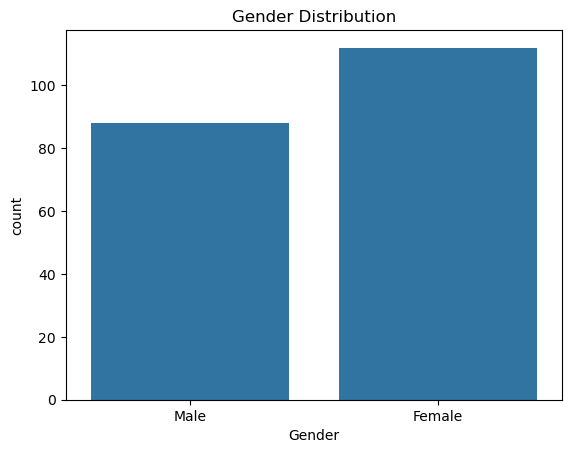

In [11]:
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.show()

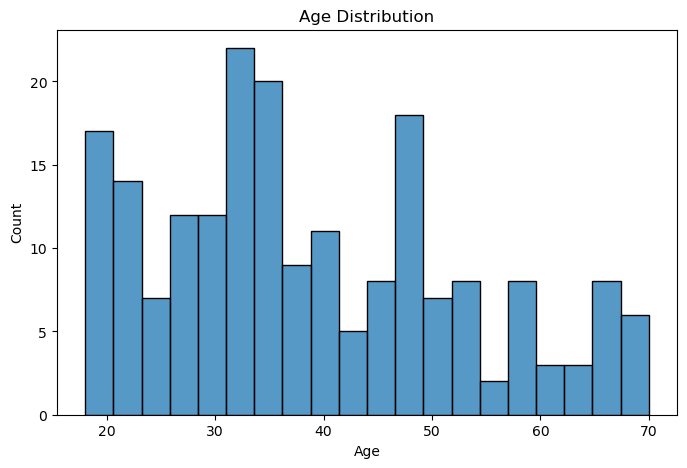

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

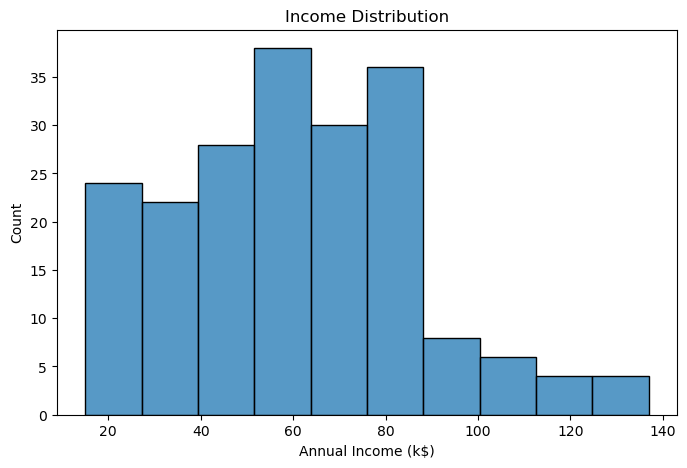

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'])

plt.title("Income Distribution")

plt.show()

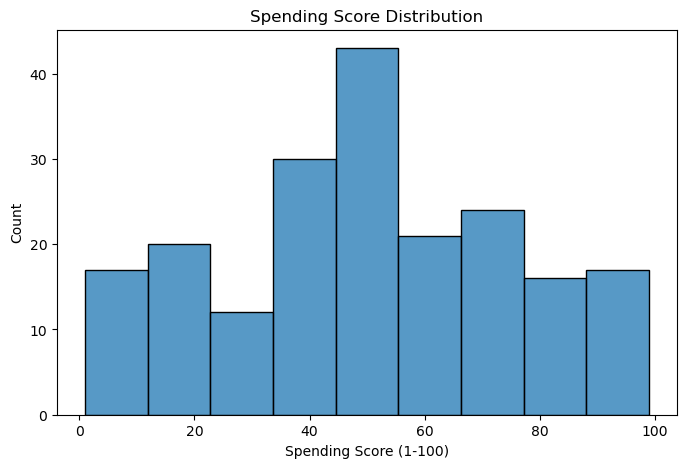

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'])

plt.title("Spending Score Distribution")

plt.show()

# Key Findings from EDA

### Gender Distribution
- Female customers slightly outnumber male customers.

### Age Distribution
- Most customers belong to the age group of 25–45 years.

### Income Distribution
- Customer income is fairly distributed across multiple ranges.

### Spending Score Distribution
- Spending behavior varies significantly among customers.

These observations indicate that customer behavior differs substantially and segmentation can provide meaningful insights.

In [16]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

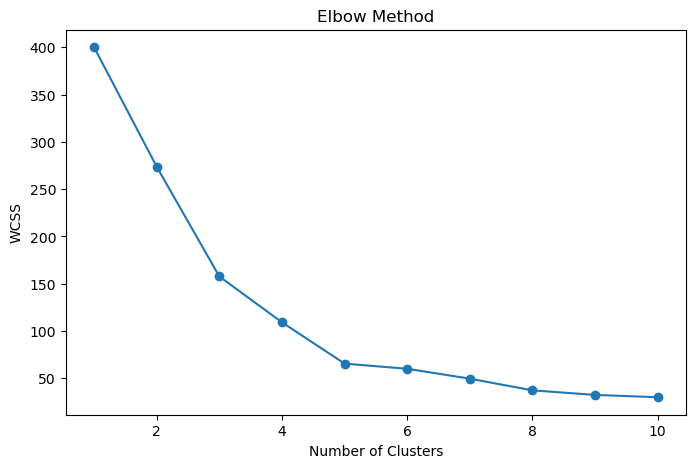

In [19]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

# Optimal Number of Clusters

The Elbow Method was used to determine the optimal value of K.

Observation:
The curve begins to flatten at K = 5.

Therefore:

Optimal Number of Clusters = 5

This value provides a balance between cluster compactness and model simplicity.

In [20]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
df['Cluster'] = clusters

In [22]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


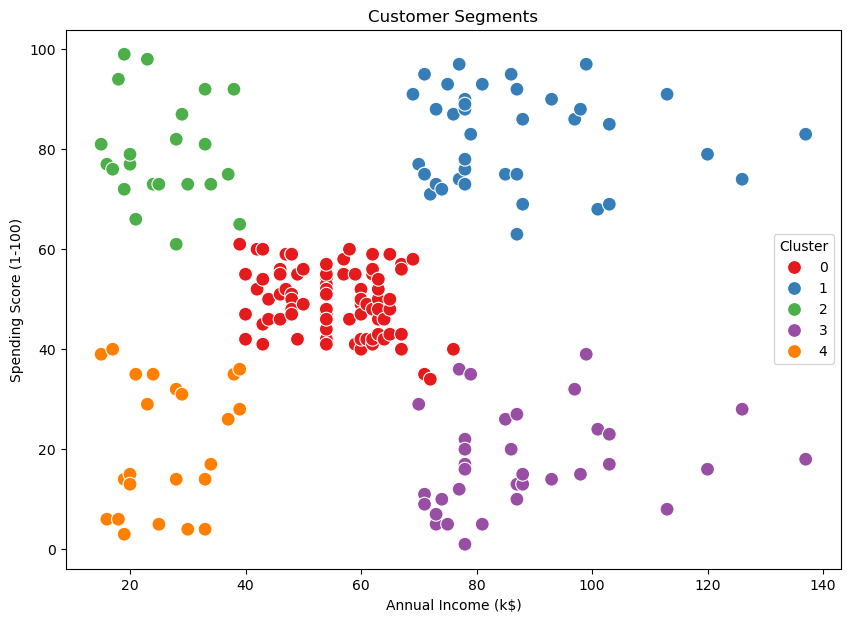

In [23]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments")

plt.show()

# Customer Segment Interpretation

## Cluster 0
Characteristics:
- Medium Income
- Medium Spending

Business Type:
Regular Customers

Recommendation:
Maintain engagement through loyalty programs.

---

## Cluster 1
Characteristics:
- High Income
- High Spending

Business Type:
Premium Customers

Recommendation:
Offer exclusive memberships and premium services.

---

## Cluster 2
Characteristics:
- Low Income
- High Spending

Business Type:
Impulse Buyers

Recommendation:
Target with promotional offers and discounts.

---

## Cluster 3
Characteristics:
- High Income
- Low Spending

Business Type:
Potential Customers

Recommendation:
Increase engagement through personalized marketing.

---

## Cluster 4
Characteristics:
- Low Income
- Low Spending

Business Type:
Low Priority Customers

Recommendation:
Focus on cost-effective marketing strategies.

In [25]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


# Results

Successfully segmented customers into 5 distinct groups using K-Means Clustering.

Achievements:

✓ Data Cleaning Completed

✓ Exploratory Data Analysis Performed

✓ Feature Scaling Applied

✓ Optimal K Identified Using Elbow Method

✓ K-Means Clustering Implemented

✓ Customer Segments Visualized

✓ Business Insights Generated

In [ ]:
# Conclusion

This project demonstrates how unsupervised machine learning can be used to understand customer behavior.

The K-Means algorithm successfully identified five unique customer segments based on income and spending patterns.

These insights can help businesses:

- Improve marketing efficiency
- Increase customer satisfaction
- Enhance customer retention
- Improve profitability

The project highlights the practical application of clustering techniques in real-world business scenarios.